# Experiment: DeepLense Test 1 - Multi-Class Lens Classification

This notebook builds a three-class classifier for DeepLense Common Test I using PyTorch.

Target labels:
- `no`: strong lensing image with no substructure
- `sphere`: subhalo substructure
- `vort`: vortex substructure

Success criteria:
- train a reproducible model
- evaluate on a stratified 90:10 validation split
- report ROC curves and AUC scores on the validation set


## Strategy and model choice

I use **PyTorch** instead of Keras because the dataset is stored as `.npy` tensors rather than JPG or PNG images, so a custom `Dataset` and explicit training loop are the most direct and transparent approach.

I use a **compact residual CNN trained from scratch** for three reasons:
- the inputs are single-channel scientific images, so the domain differs substantially from natural RGB photographs
- the dataset is balanced and reasonably large (`37,500` samples total), which is enough to train a medium CNN without relying on ImageNet weights
- a small residual network is lightweight, reproducible, and easy to run on CPU, CUDA, or Apple MPS

Training strategy:
- merge the provided folders and rebuild a **stratified 90:10 split** so the notebook exactly matches the submission rule
- use only physically plausible augmentations: flips, small rotations, and small affine perturbations
- optimize with `AdamW`, `ReduceLROnPlateau`, label smoothing, and early stopping based on **macro one-vs-rest AUC**


In [1]:
import copy
import json
import os
import random
from dataclasses import asdict, dataclass
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import swanlab
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "dataset").exists():
        return cwd
    if (cwd / "test1" / "dataset").exists():
        return cwd / "test1"
    raise FileNotFoundError("Could not locate test1/dataset from the current working directory.")


PROJECT_ROOT = resolve_project_root()
DATA_ROOT = PROJECT_ROOT / "dataset"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


@dataclass
class Config:
    seed: int = 42
    val_size: float = 0.10
    batch_size: int = 128
    num_workers: int = 0
    epochs: int = 20
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.05
    early_stopping_patience: int = 5
    max_samples_per_class: int | None = None


CONFIG = Config()

CLASS_TO_READABLE = {
    "no": "No substructure",
    "sphere": "Subhalo substructure",
    "vort": "Vortex substructure",
}
CLASS_NAMES = sorted(CLASS_TO_READABLE)
READABLE_CLASS_NAMES = [CLASS_TO_READABLE[name] for name in CLASS_NAMES]
LABEL_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
INDEX_TO_LABEL = {idx: name for name, idx in LABEL_TO_INDEX.items()}


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(CONFIG.seed)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATA_ROOT}")
print(f"Artifacts dir: {ARTIFACTS_DIR}")
print(f"Device: {device}")
print(pd.Series(asdict(CONFIG), name="value"))


Project root: /Users/colin/Projects/02_Personal/deeplence/test1
Dataset root: /Users/colin/Projects/02_Personal/deeplence/test1/dataset
Artifacts dir: /Users/colin/Projects/02_Personal/deeplence/test1/artifacts
Device: mps
seed                        42.0000
val_size                     0.1000
batch_size                 128.0000
num_workers                  0.0000
epochs                      20.0000
learning_rate                0.0003
weight_decay                 0.0001
label_smoothing              0.0500
early_stopping_patience      5.0000
max_samples_per_class           NaN
Name: value, dtype: float64


In [ ]:
SWANLAB_RUN = None
USE_SWANLAB = True

if USE_SWANLAB:
    swanlab_api_key = os.getenv("SWANLAB_API_KEY")
    if swanlab_api_key:
        swanlab.login(api_key=swanlab_api_key)

    swanlab_config = {
        **asdict(CONFIG),
        "model_name": "LensResNet",
        "dataset_name": "DeepLense Common Test I",
        "input_shape": [1, 150, 150],
        "num_classes": len(CLASS_NAMES),
        "class_names": CLASS_NAMES,
        "optimizer": "AdamW",
        "scheduler": "ReduceLROnPlateau",
        "selection_metric": "validation_macro_auc",
        "device": str(device),
    }

    try:
        SWANLAB_RUN = swanlab.init(
            project="deeplense-common-test1",
            experiment_name=f"lensresnet-seed{CONFIG.seed}",
            description="Residual CNN baseline for DeepLense Common Test I multi-class classification.",
            config=swanlab_config,
            logdir=str(ARTIFACTS_DIR / "swanlog"),
        )
        try:
            print(f"SwanLab URL: {SWANLAB_RUN.get_url()}")
        except Exception:
            print("SwanLab run initialized.")
    except Exception as exc:
        SWANLAB_RUN = None
        print(f"SwanLab init failed: {exc}")
else:
    print("SwanLab logging is disabled.")

In [2]:
def collect_file_paths(data_root: Path, max_samples_per_class: int | None = None):
    all_paths: list[Path] = []
    all_labels: list[int] = []

    for class_name in CLASS_NAMES:
        class_paths = sorted(data_root.glob(f"* /{class_name}/*.npy".replace(" ", "")))
        if max_samples_per_class is not None:
            sampler = random.Random(CONFIG.seed + LABEL_TO_INDEX[class_name])
            class_paths = sorted(sampler.sample(class_paths, k=min(max_samples_per_class, len(class_paths))))

        all_paths.extend(class_paths)
        all_labels.extend([LABEL_TO_INDEX[class_name]] * len(class_paths))

    return all_paths, all_labels


all_paths, all_labels = collect_file_paths(DATA_ROOT, CONFIG.max_samples_per_class)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=CONFIG.val_size,
    stratify=all_labels,
    random_state=CONFIG.seed,
)

train_df = pd.DataFrame(
    {
        "split": "train",
        "path": [str(path) for path in train_paths],
        "label_idx": train_labels,
        "class_name": [INDEX_TO_LABEL[label] for label in train_labels],
        "class_readable": [CLASS_TO_READABLE[INDEX_TO_LABEL[label]] for label in train_labels],
    }
)
val_df = pd.DataFrame(
    {
        "split": "val",
        "path": [str(path) for path in val_paths],
        "label_idx": val_labels,
        "class_name": [INDEX_TO_LABEL[label] for label in val_labels],
        "class_readable": [CLASS_TO_READABLE[INDEX_TO_LABEL[label]] for label in val_labels],
    }
)
split_df = pd.concat([train_df, val_df], ignore_index=True)

split_manifest_path = ARTIFACTS_DIR / "split_manifest.csv"
split_df.to_csv(split_manifest_path, index=False)

distribution = (
    split_df.groupby(["split", "class_readable"])
    .size()
    .rename("count")
    .reset_index()
    .pivot(index="class_readable", columns="split", values="count")
    .fillna(0)
    .astype(int)
)
distribution["train_fraction"] = distribution["train"] / distribution["train"].sum()
distribution["val_fraction"] = distribution["val"] / distribution["val"].sum()

display(distribution)
print(f"Total samples: {len(split_df):,}")
print(f"Train samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"Saved exact split manifest to: {split_manifest_path}")


split,train,val,train_fraction,val_fraction
class_readable,,,,
No substructure,11250,1250,0.333333,0.333333
Subhalo substructure,11250,1250,0.333333,0.333333
Vortex substructure,11250,1250,0.333333,0.333333


Total samples: 37,500
Train samples: 33,750
Validation samples: 3,750
Saved exact split manifest to: /Users/colin/Projects/02_Personal/deeplence/test1/artifacts/split_manifest.csv


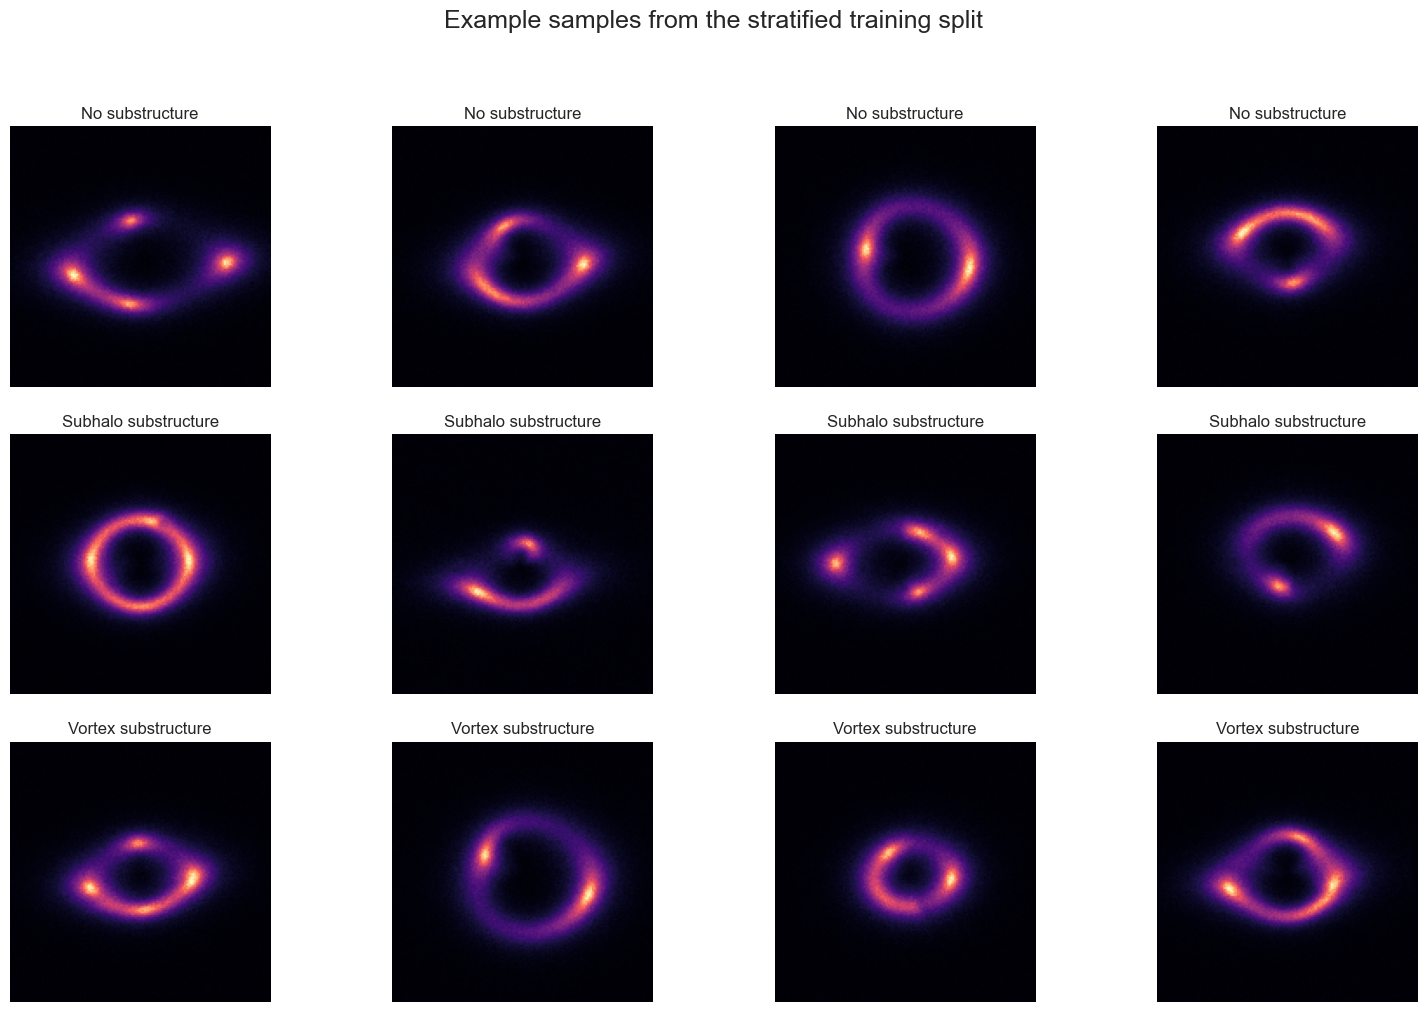

In [3]:
def plot_class_samples(frame: pd.DataFrame, samples_per_class: int = 4) -> None:
    fig, axes = plt.subplots(len(CLASS_NAMES), samples_per_class, figsize=(4 * samples_per_class, 10))

    for row_idx, class_name in enumerate(CLASS_NAMES):
        class_frame = frame[frame["class_name"] == class_name].head(samples_per_class)
        for col_idx, (_, row) in enumerate(class_frame.iterrows()):
            image = np.load(row["path"]).astype(np.float32).squeeze(0)
            ax = axes[row_idx, col_idx]
            ax.imshow(image, cmap="magma")
            ax.set_title(CLASS_TO_READABLE[class_name], fontsize=12)
            ax.axis("off")

    plt.suptitle("Example samples from the stratified training split", y=1.02, fontsize=18)
    plt.tight_layout()
    plt.show()


plot_class_samples(train_df, samples_per_class=4)


In [4]:
def compute_mean_std(paths: list[Path]) -> tuple[float, float]:
    total_sum = 0.0
    total_sq_sum = 0.0
    total_pixels = 0

    for path in paths:
        array = np.load(path).astype(np.float32)
        total_sum += float(array.sum())
        total_sq_sum += float(np.square(array).sum())
        total_pixels += array.size

    mean = total_sum / total_pixels
    variance = (total_sq_sum / total_pixels) - (mean ** 2)
    std = float(np.sqrt(max(variance, 1e-12)))
    return float(mean), std


stats_path = ARTIFACTS_DIR / "train_stats.json"
if stats_path.exists():
    with stats_path.open("r", encoding="utf-8") as handle:
        cached_stats = json.load(handle)
    train_mean = float(cached_stats["mean"])
    train_std = float(cached_stats["std"])
else:
    train_mean, train_std = compute_mean_std(train_paths)
    with stats_path.open("w", encoding="utf-8") as handle:
        json.dump({"mean": train_mean, "std": train_std}, handle, indent=2)

train_std = max(train_std, 1e-6)
print(f"Training mean: {train_mean:.6f}")
print(f"Training std: {train_std:.6f}")
print(f"Cached stats at: {stats_path}")


Training mean: 0.061704
Training std: 0.117319
Cached stats at: /Users/colin/Projects/02_Personal/deeplence/test1/artifacts/train_stats.json


In [5]:
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20, interpolation=InterpolationMode.BILINEAR),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.Normalize(mean=[train_mean], std=[train_std]),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Normalize(mean=[train_mean], std=[train_std]),
    ]
)


class LensDataset(Dataset):
    def __init__(self, paths: list[Path], labels: list[int], transform=None):
        self.paths = [Path(path) for path in paths]
        self.labels = list(labels)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        array = np.load(self.paths[index]).astype(np.float32)
        image = torch.from_numpy(array)
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(self.labels[index], dtype=torch.long)
        return image, label


train_dataset = LensDataset(train_paths, train_labels, transform=train_transform)
val_dataset = LensDataset(val_paths, val_labels, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=True,
    num_workers=CONFIG.num_workers,
    pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=False,
    num_workers=CONFIG.num_workers,
    pin_memory=(device.type == "cuda"),
)

sample_images, sample_labels = next(iter(train_loader))
print(f"Batch image tensor shape: {tuple(sample_images.shape)}")
print(f"Batch label tensor shape: {tuple(sample_labels.shape)}")
print(f"Image dtype: {sample_images.dtype}")


Batch image tensor shape: (128, 1, 150, 150)
Batch label tensor shape: (128,)
Image dtype: torch.float32


In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.shortcut(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = x + residual
        x = self.act(x)
        return x


class LensResNet(nn.Module):
    def __init__(self, num_classes: int = 3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 32, stride=1),
            ResidualBlock(32, 32, stride=1),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64, stride=1),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128, stride=1),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=1),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = self.head(x)
        return x


def initialize_weights(module: nn.Module) -> None:
    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
    elif isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)


def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


model = LensResNet(num_classes=len(CLASS_NAMES))
model.apply(initialize_weights)
model = model.to(device)

print(model)
print(f"Trainable parameters: {count_parameters(model):,}")


LensResNet(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
      (conv2): Conv2d(32, 32, 

In [7]:
@torch.no_grad()
def evaluate(model: nn.Module, data_loader: DataLoader, criterion: nn.Module):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)
        probabilities = torch.softmax(logits, dim=1)

        total_loss += loss.item() * images.size(0)
        all_labels.append(labels.detach().cpu())
        all_probabilities.append(probabilities.detach().cpu())

    labels_np = torch.cat(all_labels).numpy()
    probabilities_np = torch.cat(all_probabilities).numpy()
    predictions_np = probabilities_np.argmax(axis=1)

    y_true_one_hot = label_binarize(labels_np, classes=np.arange(len(CLASS_NAMES)))
    auc_macro = roc_auc_score(labels_np, probabilities_np, multi_class="ovr", average="macro")
    auc_per_class = {
        READABLE_CLASS_NAMES[idx]: roc_auc_score(y_true_one_hot[:, idx], probabilities_np[:, idx])
        for idx in range(len(CLASS_NAMES))
    }

    return {
        "loss": total_loss / len(data_loader.dataset),
        "accuracy": float((predictions_np == labels_np).mean()),
        "auc_macro": float(auc_macro),
        "auc_per_class": auc_per_class,
        "labels": labels_np,
        "predictions": predictions_np,
        "probabilities": probabilities_np,
    }


def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
):
    model.train()
    total_loss = 0.0
    correct = 0
    seen = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += labels.size(0)

    return {
        "loss": total_loss / seen,
        "accuracy": correct / seen,
    }


def fit_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader):
    criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG.label_smoothing)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=CONFIG.learning_rate,
        weight_decay=CONFIG.weight_decay,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    best_model_path = ARTIFACTS_DIR / "test1_best_model.pt"
    history: list[dict] = []
    best_auc = -float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(1, CONFIG.epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate(model, val_loader, criterion)
        scheduler.step(val_metrics["auc_macro"])

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_record = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_auc_macro": val_metrics["auc_macro"],
            "lr": current_lr,
        }
        history.append(epoch_record)

        if SWANLAB_RUN is not None:
            swanlab_payload = {
                "train/loss": train_metrics["loss"],
                "train/accuracy": train_metrics["accuracy"],
                "val/loss": val_metrics["loss"],
                "val/accuracy": val_metrics["accuracy"],
                "val/macro_auc": val_metrics["auc_macro"],
                "lr": current_lr,
            }
            swanlab_payload.update(
                {
                    f"val_auc/{key.lower().replace(' ', '_')}": value
                    for key, value in val_metrics["auc_per_class"].items()
                }
            )
            swanlab.log(swanlab_payload, step=epoch)

        print(
            f"Epoch {epoch:02d}/{CONFIG.epochs} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_auc={val_metrics['auc_macro']:.4f} | "
            f"lr={current_lr:.2e}"
        )

        if val_metrics["auc_macro"] > best_auc:
            best_auc = val_metrics["auc_macro"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_state_dict": best_state,
                    "best_auc_macro": best_auc,
                    "history": history,
                    "class_names": CLASS_NAMES,
                    "config": asdict(CONFIG),
                },
                best_model_path,
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CONFIG.early_stopping_patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    return model, criterion, history_df, best_model_path


In [8]:
RUN_TRAINING = True
BEST_MODEL_PATH = ARTIFACTS_DIR / "test1_best_model.pt"

if RUN_TRAINING:
    model, criterion, history_df, BEST_MODEL_PATH = fit_model(model, train_loader, val_loader)
else:
    if not BEST_MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Checkpoint not found at {BEST_MODEL_PATH}. Set RUN_TRAINING=True or provide a saved checkpoint."
        )
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG.label_smoothing)
    history_df = pd.DataFrame(checkpoint.get("history", []))

display(history_df.tail())
print(f"Best checkpoint path: {BEST_MODEL_PATH}")


Epoch 01/20 | train_loss=1.1321 | train_acc=0.3373 | val_loss=1.1094 | val_acc=0.3331 | val_auc=0.5066 | lr=3.00e-04
Epoch 02/20 | train_loss=1.1096 | train_acc=0.3360 | val_loss=1.1038 | val_acc=0.3419 | val_auc=0.5240 | lr=3.00e-04
Epoch 03/20 | train_loss=1.1049 | train_acc=0.3423 | val_loss=1.0973 | val_acc=0.3595 | val_auc=0.5296 | lr=3.00e-04
Epoch 04/20 | train_loss=1.1004 | train_acc=0.3482 | val_loss=1.2057 | val_acc=0.3328 | val_auc=0.5346 | lr=3.00e-04
Epoch 05/20 | train_loss=0.9433 | train_acc=0.5345 | val_loss=0.9181 | val_acc=0.6061 | val_auc=0.8213 | lr=3.00e-04
Epoch 06/20 | train_loss=0.6779 | train_acc=0.7378 | val_loss=0.5729 | val_acc=0.8080 | val_auc=0.9400 | lr=3.00e-04
Epoch 07/20 | train_loss=0.4909 | train_acc=0.8495 | val_loss=0.4776 | val_acc=0.8552 | val_auc=0.9703 | lr=3.00e-04
Epoch 08/20 | train_loss=0.4096 | train_acc=0.8928 | val_loss=0.6709 | val_acc=0.7549 | val_auc=0.9595 | lr=3.00e-04
Epoch 09/20 | train_loss=0.3783 | train_acc=0.9093 | val_loss=0.

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_auc_macro,lr
15,16,0.310004,0.940681,0.303744,0.942400,0.989781,0.0003
16,17,0.304771,0.942696,0.313684,0.938400,0.989834,0.0003
17,18,0.301623,0.944059,0.296664,0.944800,0.991153,0.0003
18,19,0.297095,0.945896,0.309699,0.939733,0.992590,0.0003
19,20,0.294063,0.947556,0.321375,0.934400,0.992460,0.0003


Best checkpoint path: /Users/colin/Projects/02_Personal/deeplence/test1/artifacts/test1_best_model.pt


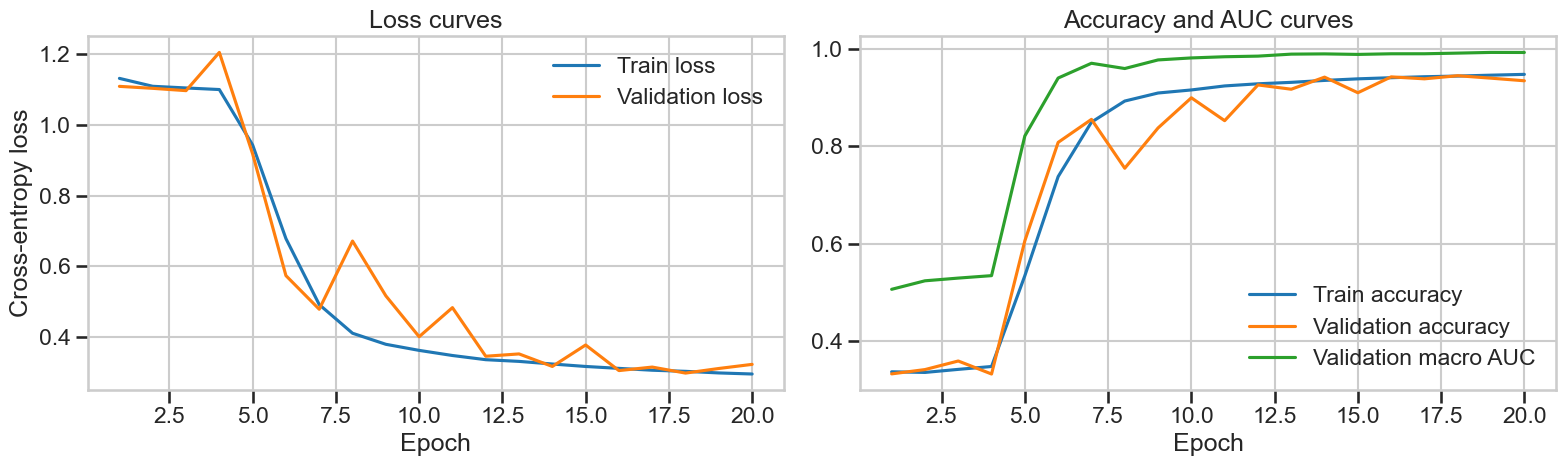

In [9]:
if not history_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    axes[0].set_title("Loss curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_auc_macro"], label="Validation macro AUC")
    axes[1].set_title("Accuracy and AUC curves")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [10]:
val_results = evaluate(model, val_loader, criterion)

summary_df = pd.DataFrame(
    {
        "metric": ["validation_loss", "validation_accuracy", "validation_macro_auc"],
        "value": [
            val_results["loss"],
            val_results["accuracy"],
            val_results["auc_macro"],
        ],
    }
)
display(summary_df)

per_class_auc_df = (
    pd.DataFrame(
        {
            "class_name": list(val_results["auc_per_class"].keys()),
            "auc": list(val_results["auc_per_class"].values()),
        }
    )
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)
display(per_class_auc_df)

report_df = pd.DataFrame(
    classification_report(
        val_results["labels"],
        val_results["predictions"],
        target_names=READABLE_CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T
display(report_df)


if SWANLAB_RUN is not None:
    final_step = int(history_df["epoch"].max()) if not history_df.empty else 0
    final_payload = {
        "final/validation_loss": val_results["loss"],
        "final/validation_accuracy": val_results["accuracy"],
        "final/validation_macro_auc": val_results["auc_macro"],
    }
    final_payload.update(
        {
            f"final_auc/{key.lower().replace(' ', '_')}": value
            for key, value in val_results["auc_per_class"].items()
        }
    )
    swanlab.log(final_payload, step=final_step)



,metric,value
0,validation_loss,0.309699
1,validation_accuracy,0.939733
2,validation_macro_auc,0.992590


,class_name,auc
0,Vortex substructure,0.995459
1,No substructure,0.993225
2,Subhalo substructure,0.989085


,precision,recall,f1-score,support
No substructure,0.945382,0.941600,0.943487,1250.000000
Subhalo substructure,0.891729,0.948800,0.919380,1250.000000
Vortex substructure,0.988085,0.928800,0.957526,1250.000000
accuracy,0.939733,0.939733,0.939733,0.939733
macro avg,0.941732,0.939733,0.940131,3750.000000
weighted avg,0.941732,0.939733,0.940131,3750.000000


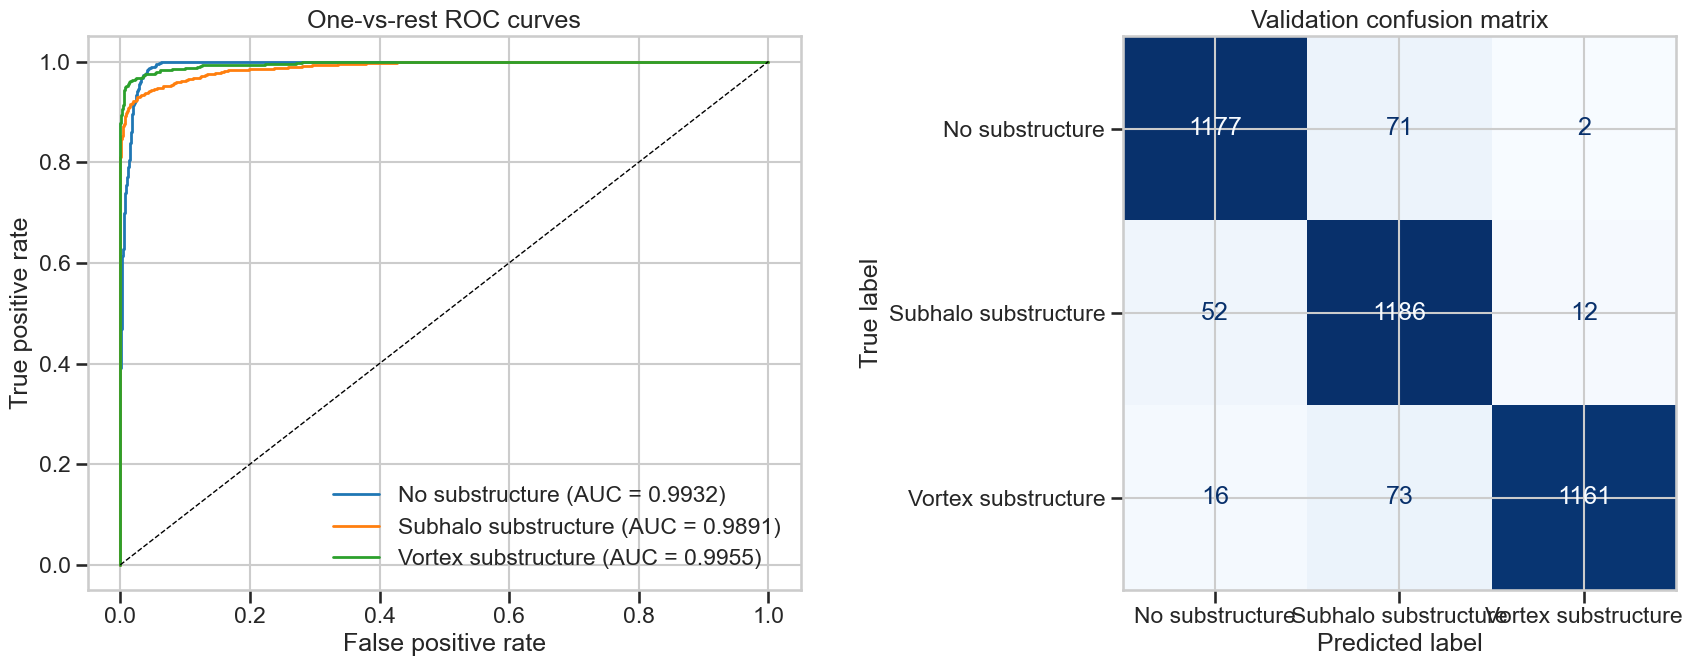

In [11]:
y_true = val_results["labels"]
y_pred = val_results["predictions"]
y_prob = val_results["probabilities"]
y_true_one_hot = label_binarize(y_true, classes=np.arange(len(CLASS_NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for class_index, class_name in enumerate(READABLE_CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, class_index], y_prob[:, class_index])
    class_auc = roc_auc_score(y_true_one_hot[:, class_index], y_prob[:, class_index])
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{class_name} (AUC = {class_auc:.4f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
axes[0].set_title("One-vs-rest ROC curves")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(loc="lower right")

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=READABLE_CLASS_NAMES,
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Validation confusion matrix")

plt.tight_layout()
plt.show()


In [ ]:
if SWANLAB_RUN is not None:
    # SwanLab requires an explicit finish() call in notebook contexts.
    swanlab.finish()

## Conclusion

This notebook provides a complete PyTorch pipeline for DeepLense Test 1:
- exact **90:10 stratified split**
- single-channel residual CNN tailored to `.npy` lens images
- validation reporting with **ROC curves** and **AUC**
- saved checkpoint and cached statistics under `test1/artifacts/`

If more time is available, the next improvements worth testing are larger residual backbones, test-time augmentation, and a lightweight hyperparameter sweep over learning rate, batch size, and augmentation strength.
